In [1]:
from pathlib import Path
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = Path("/content/drive/MyDrive/AMMCI_PRF")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "geobr==2.0.0"], check=True)
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Dados:", DATA_DIR)
print("Figuras:", FIGURE_DIR)

Dados: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\data
Figuras: D:\Workspace\ws-uem\acidentes-rodoviarios-ml\outputs\figures


# 01 — Auditoria e análise exploratória

Vamos analisar os acidentes da PRF de **2023, 2024 e janeiro de 2025**, limpar apenas problemas estruturais e separar os dados em ordem temporal.

Fonte: [dataset no Kaggle](https://www.kaggle.com/datasets/jairsouza/acidentes-rodovias-federais).
O alvo é `classificacao_acidente`: classificar uma ocorrência já registrada, usando também seu tipo e causa.

Tabelas e diagnósticos ficam no próprio notebook; as imagens são salvas em `outputs/figures/` e os splits em `data/d0.csv`, `data/d1.csv` e `data/d2.csv`.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geobr
from matplotlib.colors import Normalize
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40)
TARGET = "classificacao_acidente"
CATEGORICAL = ["dia_semana", "uf", "br", "causa_acidente", "tipo_acidente", "fase_dia",
               "sentido_via", "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo"]
NUMERIC = ["hora", "mes", "km", "latitude", "longitude", "veiculos"]

## 1. Leitura e primeira inspeção

Os CSVs usam `;` e Latin-1. `br` é lida como categoria. Conferimos colunas, tipos, datas, ausentes e duplicatas antes da limpeza. Janeiro de 2025 não representa um ano completo.

In [3]:
frames = []
periodos = {2023: ("2023-01-01", "2023-12-31"),
            2024: ("2024-01-01", "2024-12-31"),
            2025: ("2025-01-01", "2025-01-31")}

for ano, (inicio, fim) in periodos.items():
    arquivo = RAW_DIR / f"datatran{ano}.csv"
    dados = pd.read_csv(arquivo, sep=";", encoding="latin1", dtype={"br": "string"}, low_memory=False)
    print(f"\n{ano}: {dados.shape[0]:,} registros e {dados.shape[1]} colunas")
    
    display(dados.head(3))
    display(pd.DataFrame({"tipo": dados.dtypes.astype(str), "ausentes": dados.isna().sum(),
                          "% ausentes": dados.isna().mean() * 100}))
    print("Duplicatas exatas:", dados.duplicated().sum(), "| IDs repetidos:", dados.id.duplicated().sum())
    
    datas = pd.to_datetime(dados.data_inversa, format="%Y-%m-%d", errors="coerce")
    print("Período:", datas.min(), "até", datas.max())
    
    assert datas.notna().all() and datas.between(inicio, fim).all(), "Revisar datas do arquivo."
    assert datas.min() == pd.Timestamp(inicio) and datas.max() == pd.Timestamp(fim), "Período diferente do previsto."
    frames.append(dados.assign(arquivo_ano=ano))
    
df = pd.concat(frames, ignore_index=True)
print("Total:", len(df))


2023: 67,766 registros e 30 colunas


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,496519,2023-01-01,domingo,02:00:00,ES,101,114,SOORETAMA,Ausência de reação do condutor,Saída de leito carroçável,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Simples,Reta,Não,1,0,1,0,0,0,1,1,"-19,09484877","-40,05095848",SPRF-ES,DEL04-ES,UOP01-DEL04-ES
1,496543,2023-01-01,domingo,03:40:00,SP,116,"113,1",TAUBATE,Entrada inopinada do pedestre,Atropelamento de Pedestre,Com Vítimas Fatais,Plena Noite,Decrescente,Céu Claro,Dupla,Reta,Sim,5,1,0,0,0,4,0,2,"-23,0445658","-45,58259814",SPRF-SP,DEL02-SP,UOP02-DEL02-SP
2,496590,2023-01-01,domingo,01:40:00,MT,163,1112,GUARANTA DO NORTE,Reação tardia ou ineficiente do condutor,Tombamento,NaN,Plena Noite,Crescente,Ignorado,Simples,Curva;Declive,Não,2,0,0,1,0,2,1,3,"-9,70020602","-54,87588757",SPRF-MT,DEL06-MT,UOP03-DEL06-MT


,tipo,ausentes,% ausentes
id,int64,0,0.000000
data_inversa,object,0,0.000000
dia_semana,object,0,0.000000
horario,object,0,0.000000
uf,object,0,0.000000
br,string,0,0.000000
km,object,0,0.000000
municipio,object,0,0.000000
causa_acidente,object,0,0.000000
tipo_acidente,object,0,0.000000


Duplicatas exatas: 0 | IDs repetidos: 0
Período: 2023-01-01 00:00:00 até 2023-12-31 00:00:00



2024: 73,156 registros e 30 colunas


...

,tipo,ausentes,% ausentes
id,float64,0,0.000000
data_inversa,object,0,0.000000
dia_semana,object,0,0.000000
horario,object,0,0.000000
uf,object,0,0.000000
br,string,0,0.000000
km,object,0,0.000000
municipio,object,0,0.000000
causa_acidente,object,0,0.000000
tipo_acidente,object,0,0.000000


Duplicatas exatas: 0 | IDs repetidos: 0
Período: 2024-01-01 00:00:00 até 2024-12-31 00:00:00

2025: 5,478 registros e 30 colunas


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,-23.485868,-46.540753,SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,-7.812288,-39.083333,SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,-23.182565,-50.637228,SPRF-PR,DEL07-PR,UOP05-DEL07-PR


,tipo,ausentes,% ausentes
id,int64,0,0.000000
data_inversa,object,0,0.000000
dia_semana,object,0,0.000000
horario,object,0,0.000000
uf,object,0,0.000000
br,string,0,0.000000
km,object,0,0.000000
municipio,object,0,0.000000
causa_acidente,object,0,0.000000
tipo_acidente,object,0,0.000000


Duplicatas exatas: 0 | IDs repetidos: 0
Período: 2025-01-01 00:00:00 até 2025-01-31 00:00:00
Total: 146400


## 2. Limpeza simples

Nesta seção normalizamos espaços e campos vazios; convertemos números com vírgula decimal e combinamos data + horário. Falhas de conversão são mostradas e exigem revisão. Nenhuma categoria é agrupada ou corrigida automaticamente.

In [4]:
for coluna in df.select_dtypes(include=["object", "string"]).columns:
    antes = df[coluna].astype("string")
    depois = antes.str.strip().str.replace(r"\s+", " ", regex=True).replace("", pd.NA)
    alterados = (antes.fillna("<NA>") != depois.fillna("<NA>")).sum()
    
    if alterados:
        print(f"{coluna}: {alterados} valores normalizados")
        
    df[coluna] = depois

for coluna in ["km", "latitude", "longitude", "veiculos"]:
    antes = df[coluna]
    df[coluna] = pd.to_numeric(antes.astype("string").str.replace(",", ".", regex=False), errors="coerce")
    falhas = antes.notna() & df[coluna].isna()
    print(f"{coluna}: {falhas.sum()} falhas de conversão")

horario_valido = df.horario.str.fullmatch(r"(?:[01]\d|2[0-3]):[0-5]\d:[0-5]\d", na=False)
display(df.loc[~horario_valido, ["id", "data_inversa", "horario"]])

df["timestamp"] = pd.to_datetime(df.data_inversa + " " + df.horario, format="%Y-%m-%d %H:%M:%S", errors="raise")
df["hora"] = df.timestamp.dt.hour
df["mes"] = df.timestamp.dt.month
display(pd.DataFrame({"ausentes": df.isna().sum(), "% ausentes": df.isna().mean() * 100}))

df_audit = df.copy()

municipio: 20 valores normalizados


km: 0 falhas de conversão
latitude: 0 falhas de conversão
longitude: 0 falhas de conversão


veiculos: 0 falhas de conversão


,id,data_inversa,horario


,ausentes,% ausentes
id,0,0.000000
data_inversa,0,0.000000
dia_semana,0,0.000000
horario,0,0.000000
uf,0,0.000000
br,0,0.000000
km,0,0.000000
municipio,0,0.000000
causa_acidente,0,0.000000
tipo_acidente,0,0.000000


## 3. Coordenadas, valores incomuns e alvo

O retângulo continental aproximado sinaliza uma ocorrência em **Fernando de Noronha/PE** (ID 620583, BR-363). Ela será mantida e incluída no mapa. Não é um erro de coordenada.

Há **três registros sem alvo**: serão excluídos da base supervisionada, exibindo seus IDs. Não vamos inferir a classificação pelas informações de vítimas. Cópias exatamente iguais também seriam removidas e contadas; IDs repetidos com conteúdo diferente exigem revisão.

In [5]:
# sempre parte da base anterior as exclusões
df = df_audit.copy()

fora = ~df.latitude.between(-34, 6) | ~df.longitude.between(-74.5, -34)
display(df.loc[fora, ["id", "uf", "municipio", "br", "latitude", "longitude"]])

ilha = (df.id.eq(620583) & df.uf.eq("PE") & df.municipio.eq("FERNANDO DE NORONHA") & df.latitude.between(-3.9, -3.8) & df.longitude.between(-32.5, -32.3)) # tratando o caso de fernando de noronha

assert df[["latitude", "longitude"]].notna().all().all(), "Revisar coordenadas ausentes."
assert (fora & ~ilha).sum() == 0, "Revisar coordenadas sinalizadas ainda não documentadas."

impossiveis = ((df.km < 0) | (df.veiculos < 1) | (df.veiculos % 1 != 0) | ~np.isfinite(df.km) | ~np.isfinite(df.veiculos))
display(df.loc[impossiveis, ["id", "km", "veiculos"]])

assert not impossiveis.any(), "Revisar valores impossíveis."
display(df[TARGET].value_counts(dropna=False))

sem_alvo = df[TARGET].isna()
display(df.loc[sem_alvo, ["id", "arquivo_ano", "data_inversa", TARGET]])

colunas_originais = [c for c in frames[0].columns if c != "arquivo_ano"]
duplicadas = df.duplicated(subset=colunas_originais)
print("Sem alvo:", sem_alvo.sum(), "| Duplicatas exatas excedentes:", duplicadas.sum())

df = df.loc[~(sem_alvo | duplicadas)].copy()
assert df.id.notna().all() and not df.id.duplicated().any(), "Revisar IDs."
print("Registros mantidos:", len(df))

# mapeamento definido após observar as classes presentes.
CLASS_TO_INT = {"Com Vítimas Fatais": 0, "Com Vítimas Feridas": 1, "Sem Vítimas": 2}
assert set(df[TARGET].unique()) == set(CLASS_TO_INT), "Revisar classes do alvo."
display(pd.DataFrame({"quantidade": df[TARGET].value_counts(), "percentual": df[TARGET].value_counts(normalize=True) * 100}))

,id,uf,municipio,br,latitude,longitude
118735,620583.0,PE,FERNANDO DE NORONHA,363,-3.841072,-32.406822


,id,km,veiculos


classificacao_acidente
Com Vítimas Feridas    112422
Sem Vítimas             23536
Com Vítimas Fatais      10439
<NA>                        3
Name: count, dtype: Int64

,id,arquivo_ano,data_inversa,classificacao_acidente
2,496590.0,2023,2023-01-01,<NA>
67766,571789.0,2024,2024-01-01,<NA>
142297,652555.0,2025,2025-01-01,<NA>


Sem alvo: 3 | Duplicatas exatas excedentes: 0
Registros mantidos: 146397


,quantidade,percentual
classificacao_acidente,,
Com Vítimas Feridas,112422,76.792557
Sem Vítimas,23536,16.076832
Com Vítimas Fatais,10439,7.130611


## 4. Categorias e divisão temporal

`tracado_via` contém combinações como “Reta;Declive”: preservamos todos os valores. Top-N e “Outros” serão usados somente nos gráficos.

As entradas futuras são apenas `CATEGORICAL + NUMERIC`. Não usar ID, município, atributos administrativos ou quantidades de vítimas como features. As demais colunas permanecem no DataFrame para auditoria e mapas.

Ordenamos por timestamp e separamos **60% / 20% / 20%** por posição. Empates mantêm a ordem original e são exibidos. `d0`, `d1` e `d2` também são salvos em CSV na raiz de `data/`, para os próximos notebooks. Os arquivos usam UTF-8 e separador `;`. D2 não deve orientar alterações de features ou modelos.

In [6]:
for coluna in CATEGORICAL:
    print(f"\n{coluna}: {df[coluna].nunique()} categorias")
    display(df[coluna].value_counts(dropna=False).head(20))
    
print("Ausentes nas features:")
display(df[CATEGORICAL + NUMERIC].isna().sum())

ordered = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
n = len(ordered)
assert n >= 3000

corte0, corte1 = int(n * 0.6), int(n * 0.8)
d0 = ordered.iloc[:corte0].copy()
d1 = ordered.iloc[corte0:corte1].copy()
d2 = ordered.iloc[corte1:].copy()
splits = {"d0": d0, "d1": d1, "d2": d2}
display(pd.DataFrame([{"split": nome, "registros": len(parte), "%": len(parte) / n * 100,"início": parte.timestamp.min(), "fim": parte.timestamp.max()}
                      for nome, parte in splits.items()]))

print("Empate D0/D1:", d0.timestamp.max() == d1.timestamp.min())
print("Empate D1/D2:", d1.timestamp.max() == d2.timestamp.min())
assert len(d0) + len(d1) + len(d2) == len(ordered)
assert d0.timestamp.max() <= d1.timestamp.min() <= d1.timestamp.max() <= d2.timestamp.min()

# Salva os dados estruturais, sem encoder, scaler ou imputação.
for nome, parte in splits.items():
    arquivo = DATA_DIR / f"{nome}.csv"
    parte.to_csv(arquivo, sep=";", encoding="utf-8", index=False)
    print(f"Salvo: {arquivo.name} ({len(parte):,} registros)")


dia_semana: 7 categorias


dia_semana
domingo          23792
sábado           23501
sexta-feira      22594
segunda-feira    20198
quinta-feira     19297
quarta-feira     18730
terça-feira      18285
Name: count, dtype: Int64


uf: 27 categorias


uf
MG    19047
SC    16790
PR    15289
RJ    12451
RS    10543
SP     9983
BA     8226
GO     6670
PE     6447
MT     5076
ES     4806
PB     3682
MS     3651
RN     3095
RO     2979
CE     2972
PI     2910
MA     2365
DF     2100
PA     1929
Name: count, dtype: Int64


br: 122 categorias


...

,split,registros,%,início,fim
0,d0,87838,59.999863,2023-01-01 00:01:00,2024-04-17 07:50:00
1,d1,29279,19.999727,2024-04-17 07:50:00,2024-09-08 15:30:00
2,d2,29280,20.000410,2024-09-08 15:30:00,2025-01-31 23:30:00


Empate D0/D1: True
Empate D1/D2: True


Salvo: d0.csv (87,838 registros)


Salvo: d1.csv (29,279 registros)


Salvo: d2.csv (29,280 registros)


## 5. Análise exploratória

As funções abaixo apenas evitam repetir a formatação dos gráficos.

Contagens descrevem ocorrências registradas, não risco por volume de tráfego. A distribuição agregada por mês contém três janeiros e dois exemplares dos demais meses.

In [7]:
CLASS_COLORS = {"Com Vítimas Fatais": "#ba3b46", "Com Vítimas Feridas": "#dc9b33", "Sem Vítimas": "#337a98"}

def save_figure(fig, path):
    fig.savefig(path, dpi=180, bbox_inches="tight", facecolor="white")

def count_plot(series, title, path, top_n=12, order=None):
    counts = series.fillna("Ausente").value_counts()
    if order is not None:
        counts = counts.reindex(order, fill_value=0)
    elif len(counts) > top_n:
        counts = pd.concat([counts.iloc[:top_n], pd.Series({"Outros (visualização)": counts.iloc[top_n:].sum()})])
        
    fig, ax = plt.subplots(figsize=(11, max(4, len(counts) * 0.36)))
    counts.iloc[::-1].plot.barh(ax=ax, color="#337a98")
    ax.set(title=title, xlabel="Número de acidentes", ylabel="")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    save_figure(fig, path)
    return fig

def target_relation(df, column, path, top_n=10):
    frequent = df[column].value_counts().head(top_n).index
    labels = df[column].fillna("Ausente").where(df[column].isin(frequent), "Outros / ausente (visualização)")
    counts = pd.crosstab(labels, df[TARGET])
    proportions = counts.div(counts.sum(axis=1), axis=0)
    
    fig, ax = plt.subplots(figsize=(11, max(4, len(counts) * 0.4)))
    proportions.plot.barh(stacked=True, ax=ax, color=[CLASS_COLORS[c] for c in proportions.columns])
    
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=f"Classificação por {column}", xlabel="Proporção dos acidentes em cada categoria", ylabel="")
    ax.legend(title="Classificação", bbox_to_anchor=(1.01, 1), loc="upper left")
    fig.tight_layout()
    save_figure(fig, path)
    
    return fig, counts

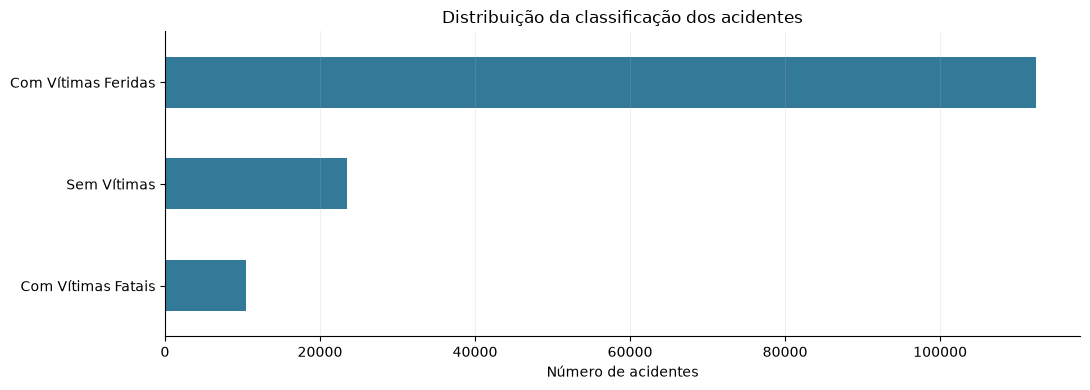

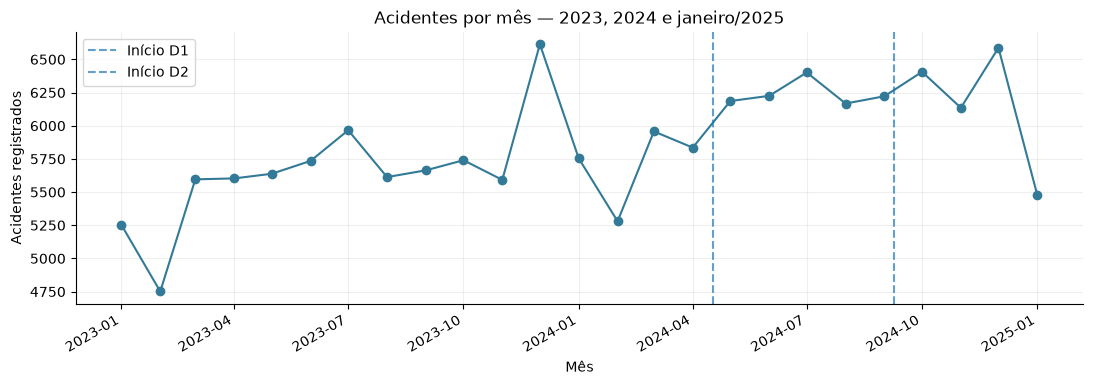

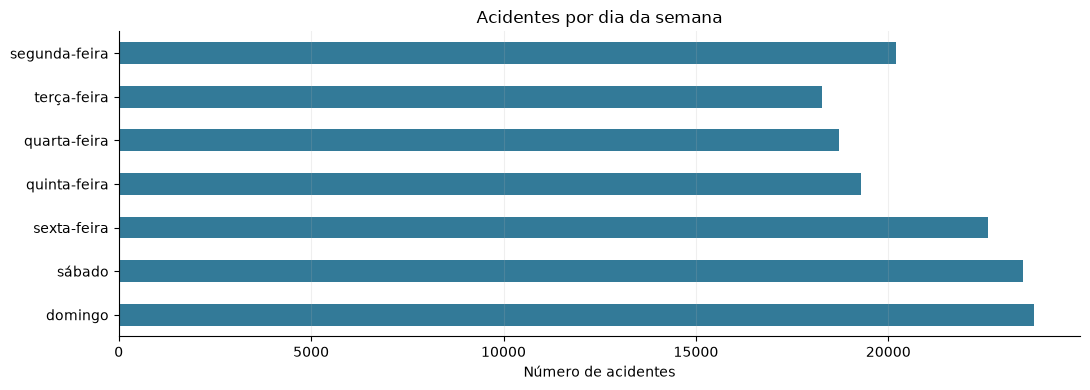

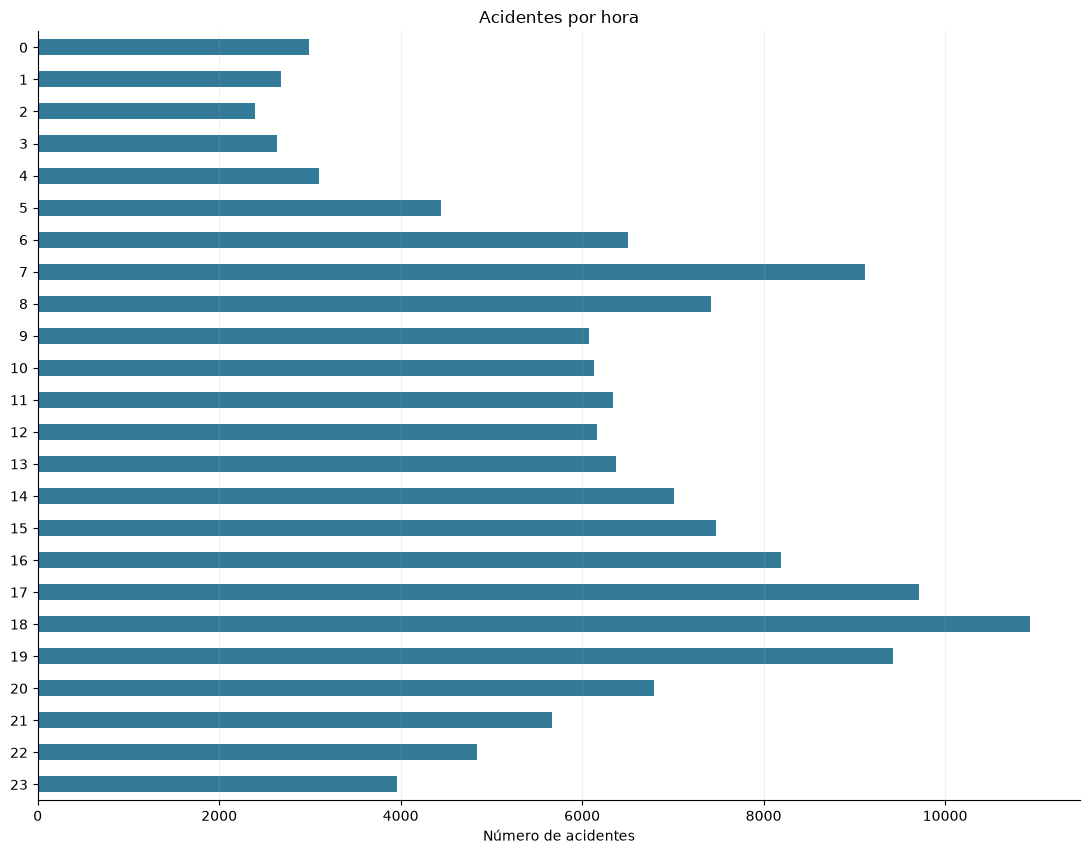

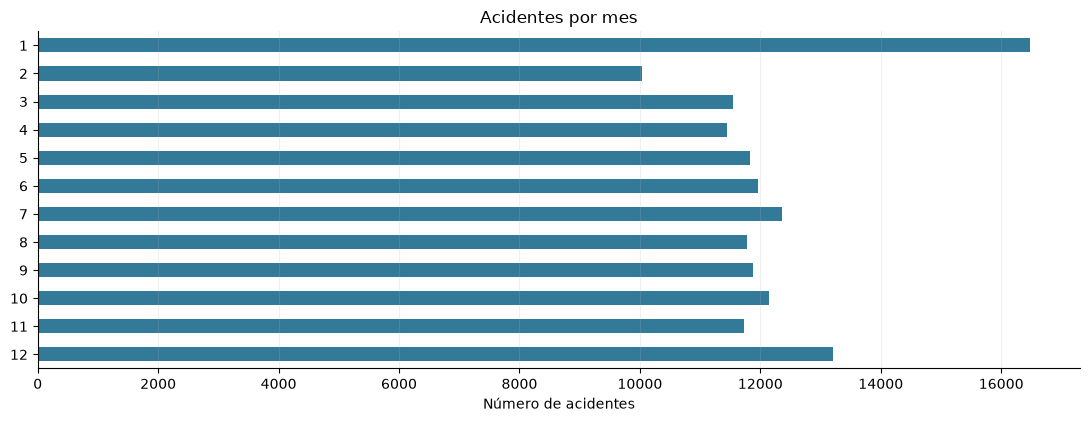

A distribuição agregada por mês contém três janeiros e dois exemplares dos demais meses.


In [8]:
fig = count_plot(ordered[TARGET], "Distribuição da classificação dos acidentes", FIGURE_DIR / "eda_target.png")
plt.show()

monthly = ordered.groupby(ordered.timestamp.dt.to_period("M")).size()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.index.to_timestamp(), monthly.values, marker="o", color="#337a98")

for name in ["d1", "d2"]:
    ax.axvline(splits[name].timestamp.min(), linestyle="--", label=f"Início {name.upper()}", alpha=0.7)
    
ax.set(title="Acidentes por mês — 2023, 2024 e janeiro/2025", xlabel="Mês", ylabel="Acidentes registrados")
ax.legend()
ax.grid(alpha=0.2)
fig.autofmt_xdate()
save_figure(fig, FIGURE_DIR / "eda_monthly.png")
plt.show()

week_order = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"]
assert set(ordered.dia_semana.unique()) <= set(week_order), "Revisar grafias dos dias da semana."
fig = count_plot(ordered.dia_semana, "Acidentes por dia da semana", FIGURE_DIR / "eda_dia_semana.png", order=week_order)
plt.show()

for column, order in [("hora", list(range(24))), ("mes", list(range(1, 13)))]:
    fig = count_plot(ordered[column], f"Acidentes por {column}", FIGURE_DIR / f"eda_{column}.png", order=order)
    plt.show()
    
print("A distribuição agregada por mês contém três janeiros e dois exemplares dos demais meses.")

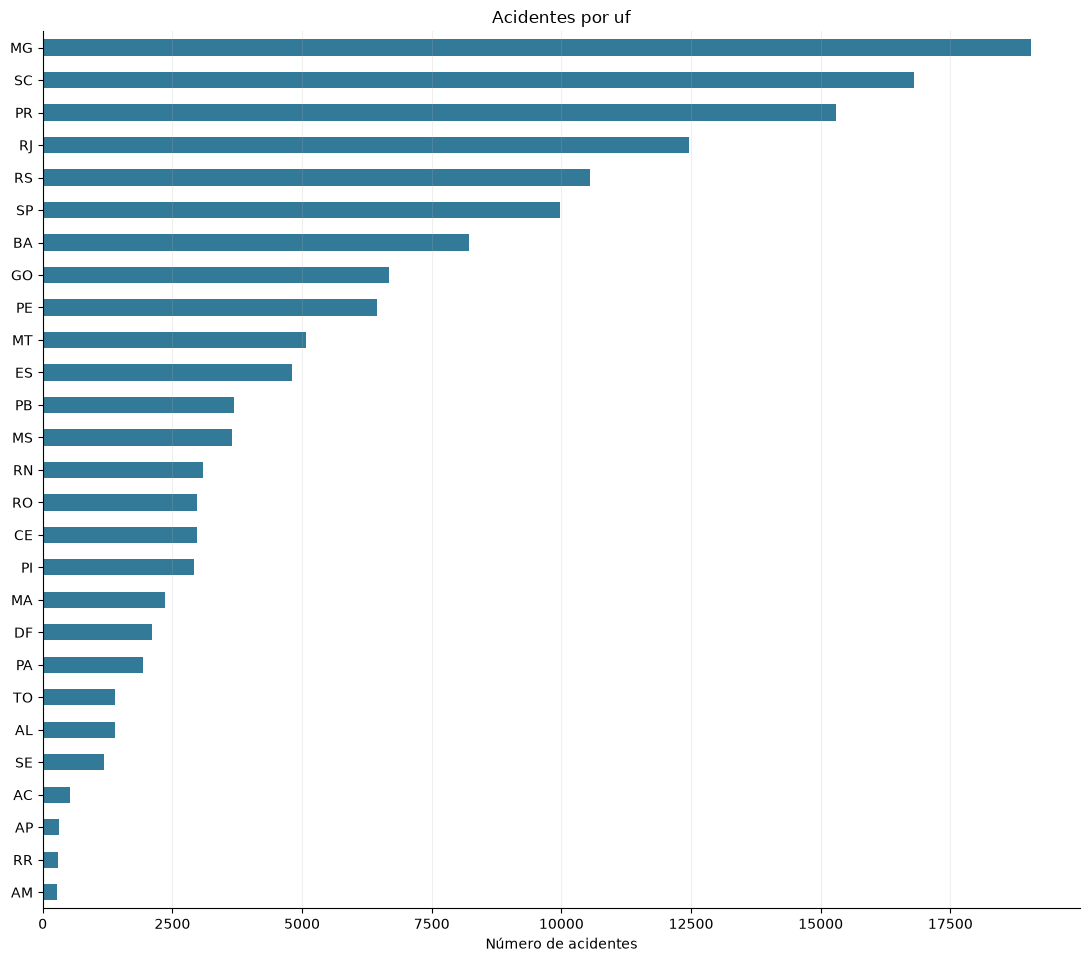

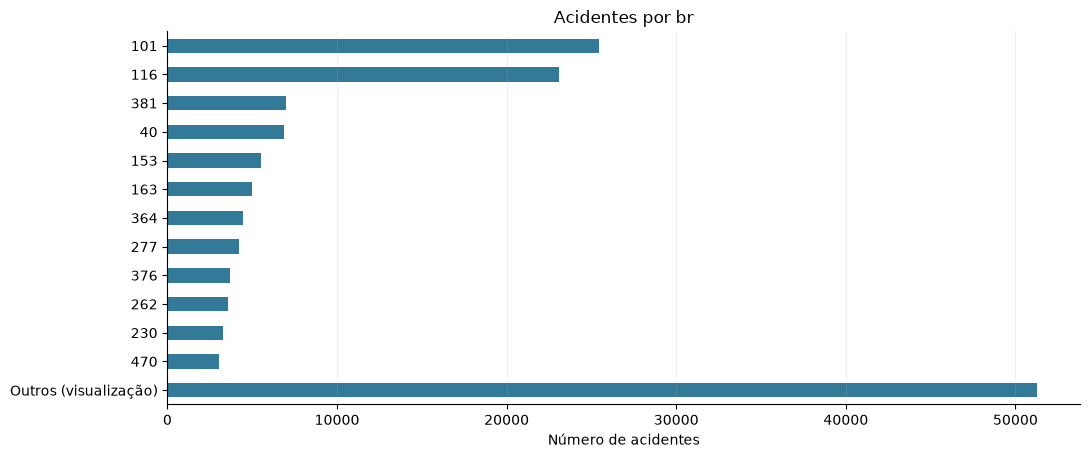

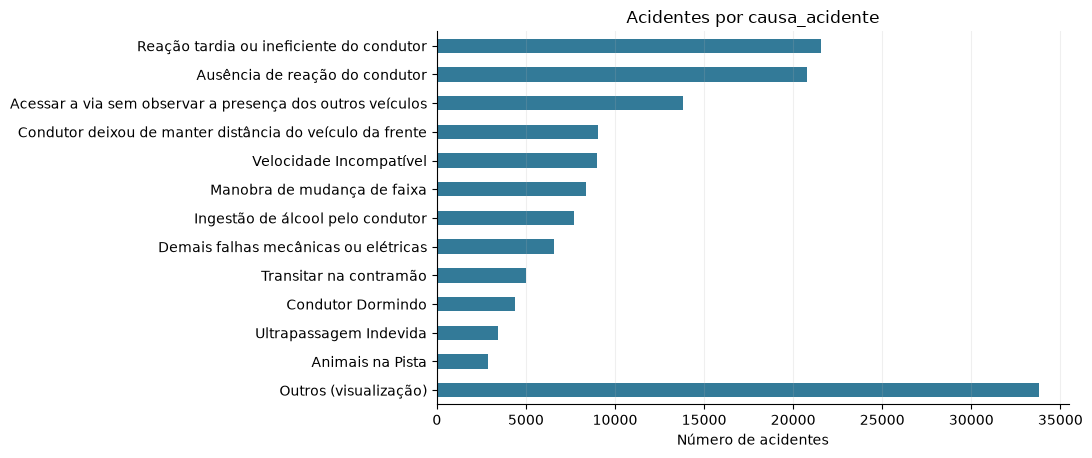

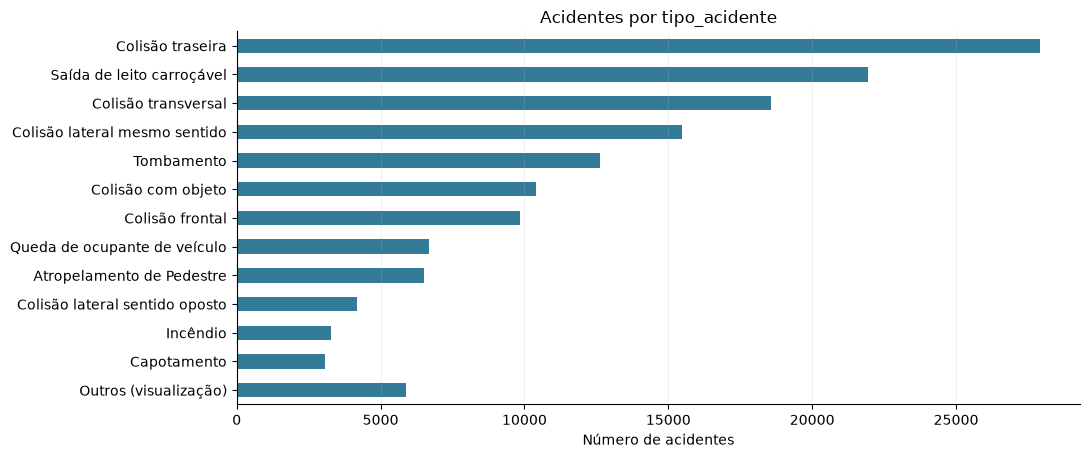

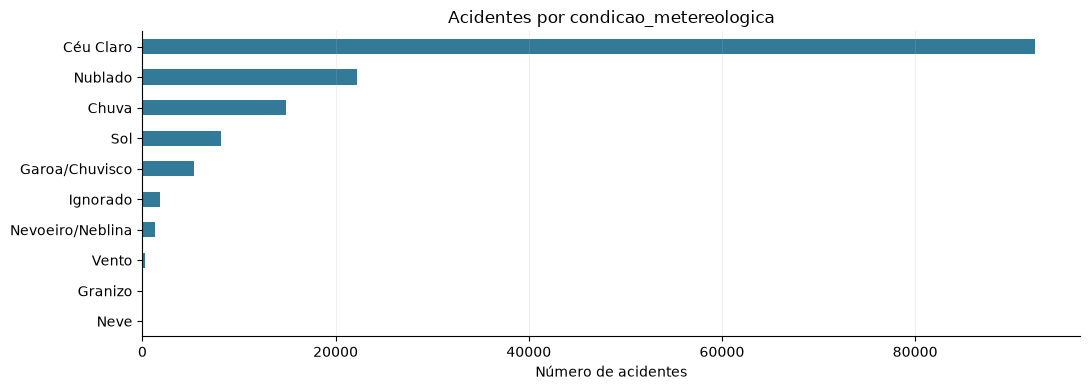

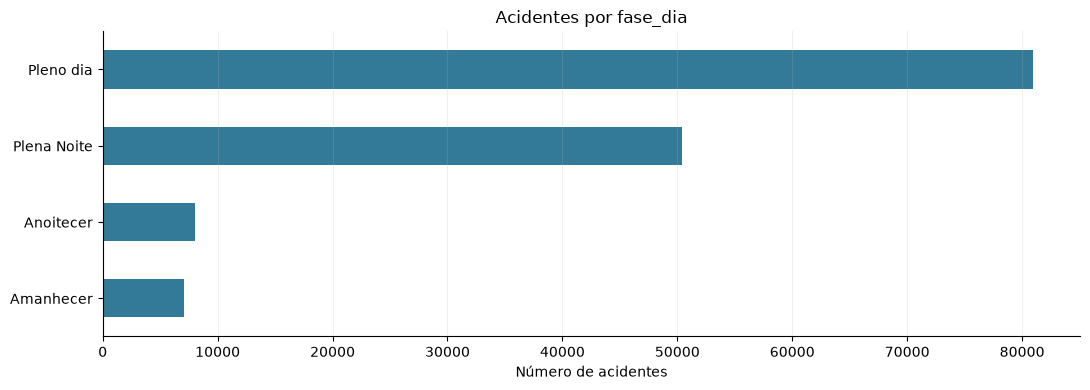

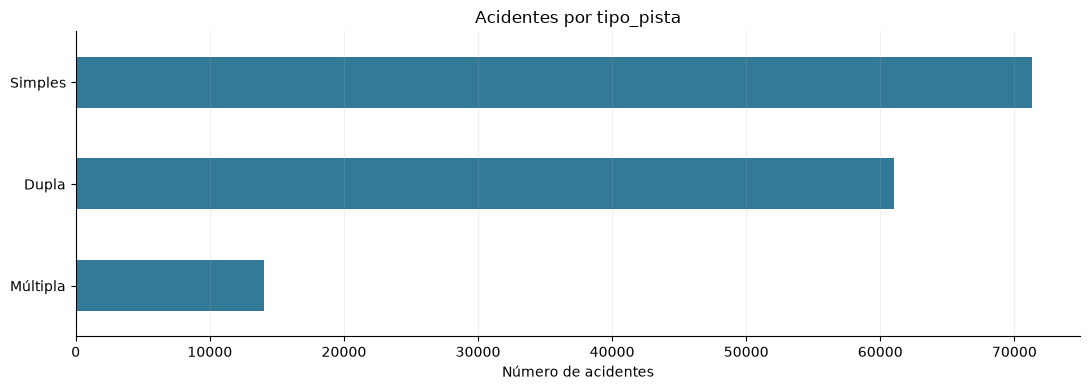

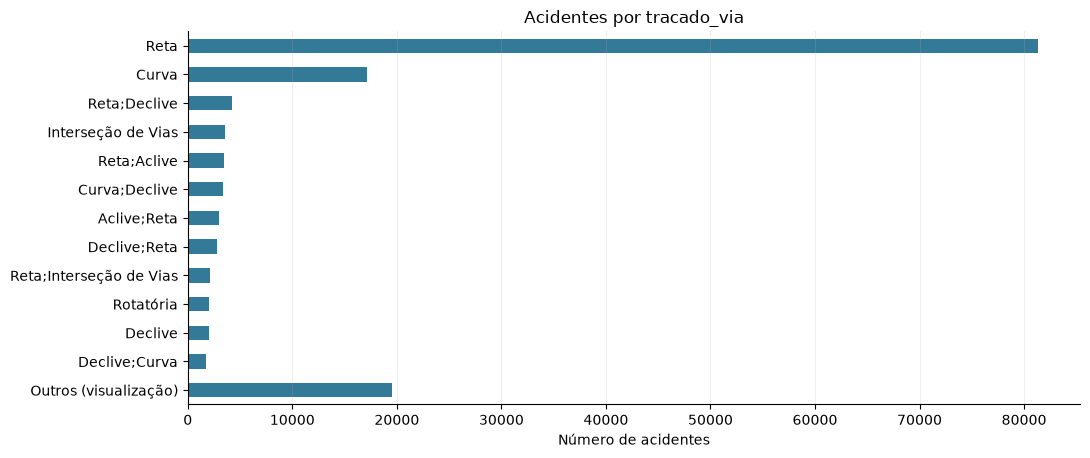

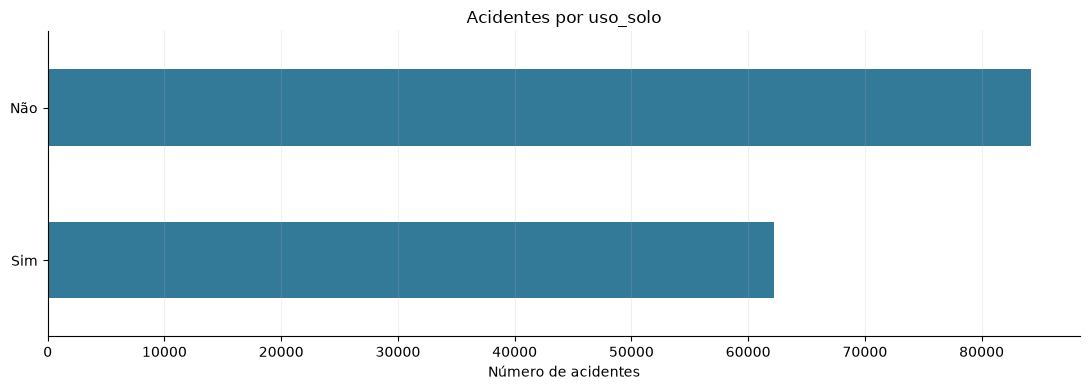

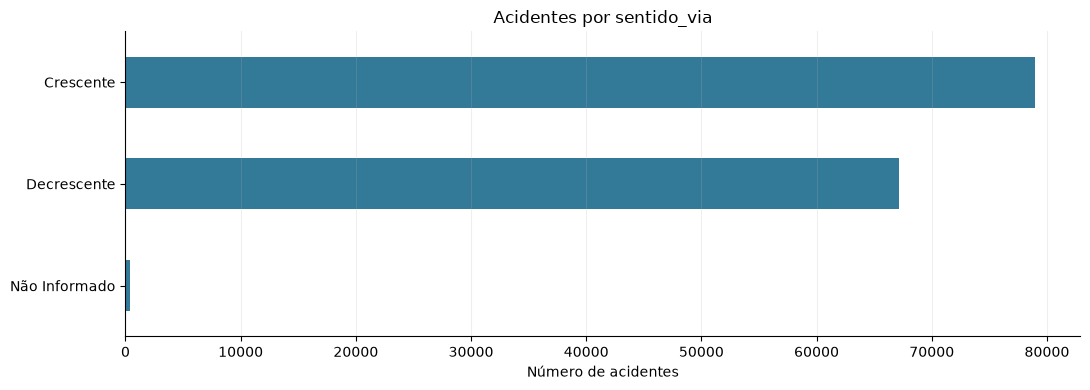

,count,mean,std,min,1%,50%,99%,max
hora,146397.0,12.90883,6.049837,0.0,0.0,14.0,23.0,23.0
mes,146397.0,6.45156,3.538967,1.0,1.0,6.0,12.0,12.0
km,146397.0,259.184044,227.080626,0.0,1.0,194.0,908.1,1470.0
latitude,146397.0,-18.876034,7.701659,-33.680584,-30.430867,-20.446006,-2.53073,4.476284
longitude,146397.0,-46.442047,6.180467,-72.641548,-63.32771,-47.182743,-34.905881,-32.406822
veiculos,146397.0,1.990656,1.1462,1.0,1.0,2.0,6.0,131.0


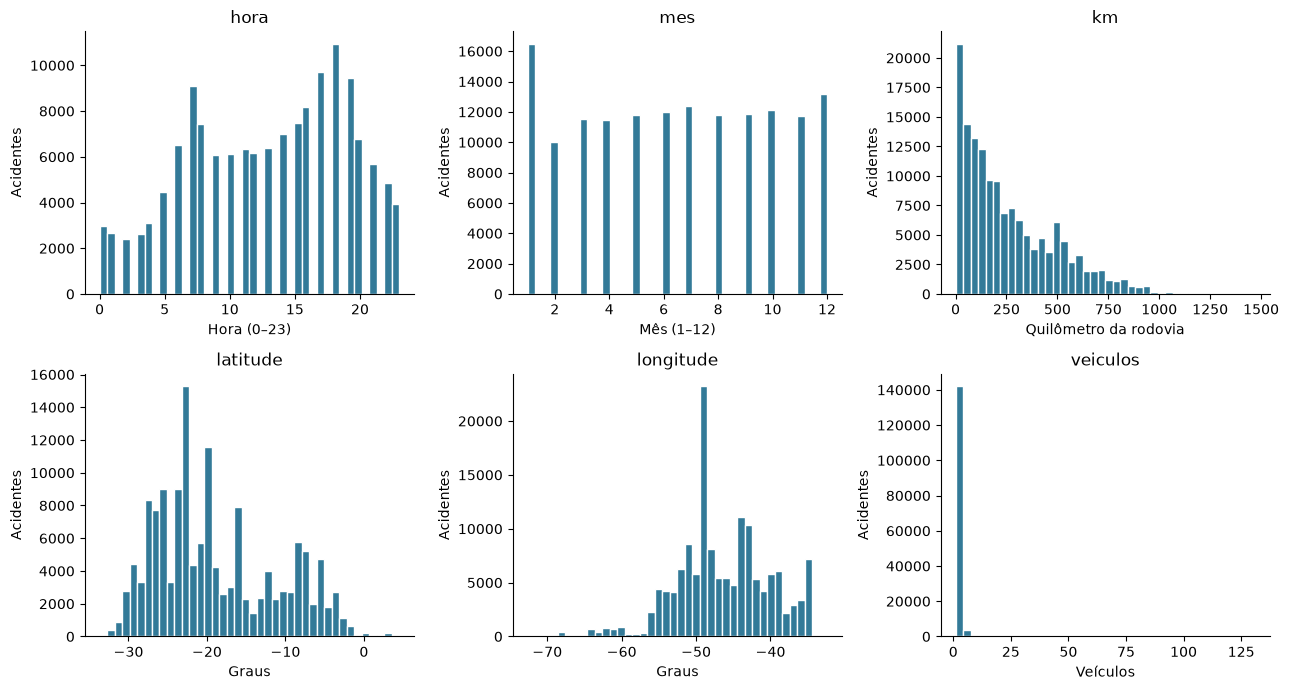

In [9]:
for column in ["uf", "br", "causa_acidente", "tipo_acidente", "condicao_metereologica",
               "fase_dia", "tipo_pista", "tracado_via", "uso_solo", "sentido_via"]:
    fig = count_plot(ordered[column], f"Acidentes por {column}", FIGURE_DIR / f"eda_{column}.png",
                     top_n=27 if column == "uf" else 12)
    plt.show()

numeric_summary = ordered[NUMERIC].describe(percentiles=[0.01, 0.5, 0.99]).T
display(numeric_summary)
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for column, ax in zip(NUMERIC, axes.flat):
    ax.hist(ordered[column].dropna().astype(float), bins=40, color="#337a98", edgecolor="white")
    ax.set(title=column, xlabel={"km": "Quilômetro da rodovia", "latitude": "Graus",
                                "longitude": "Graus", "veiculos": "Veículos",
                                "hora": "Hora (0–23)", "mes": "Mês (1–12)"}[column],
           ylabel="Acidentes")
    
fig.tight_layout()
save_figure(fig, FIGURE_DIR / "eda_numeric.png")
plt.show()

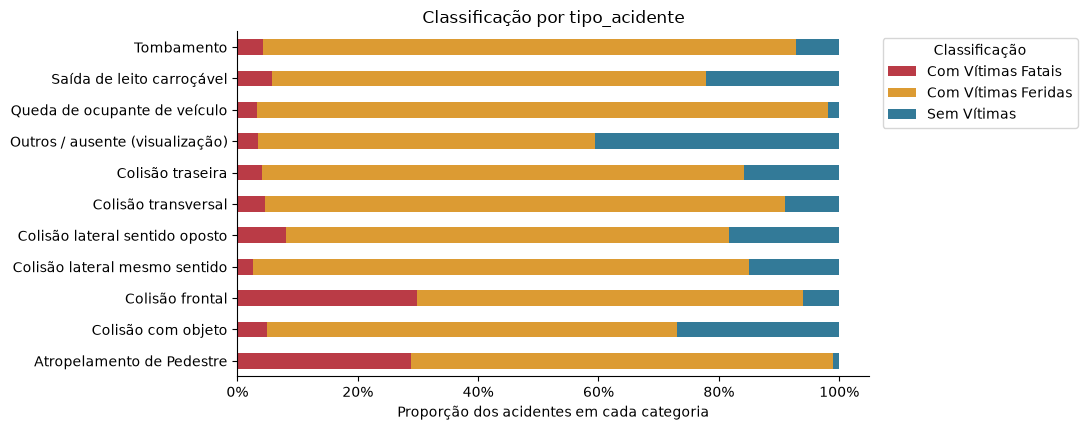

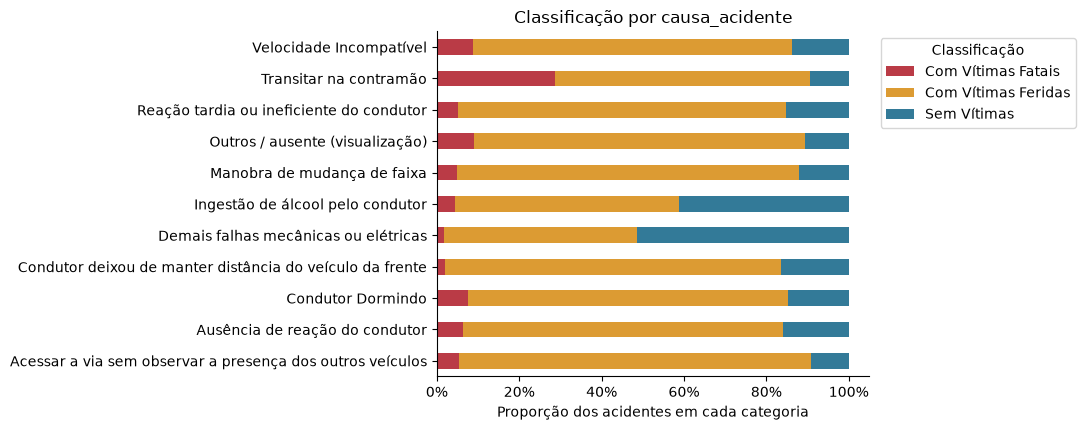

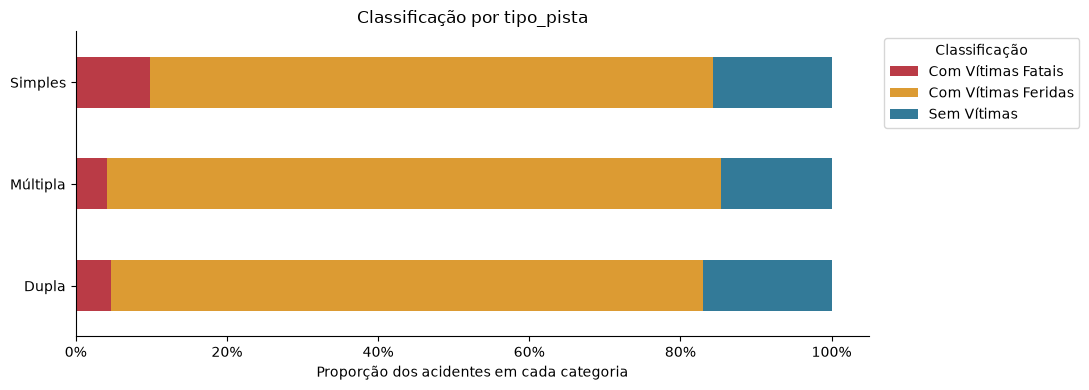

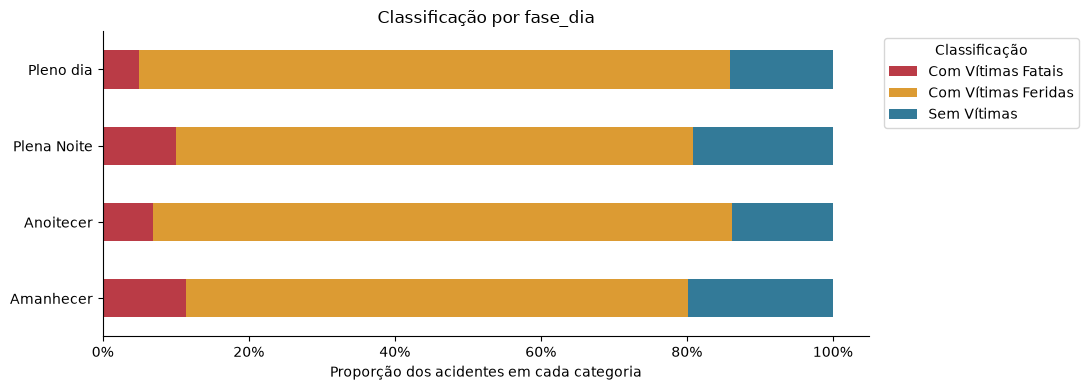

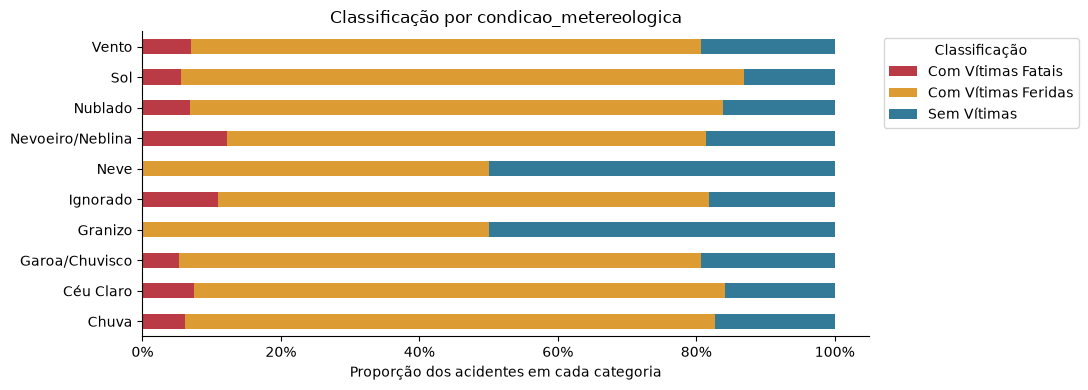

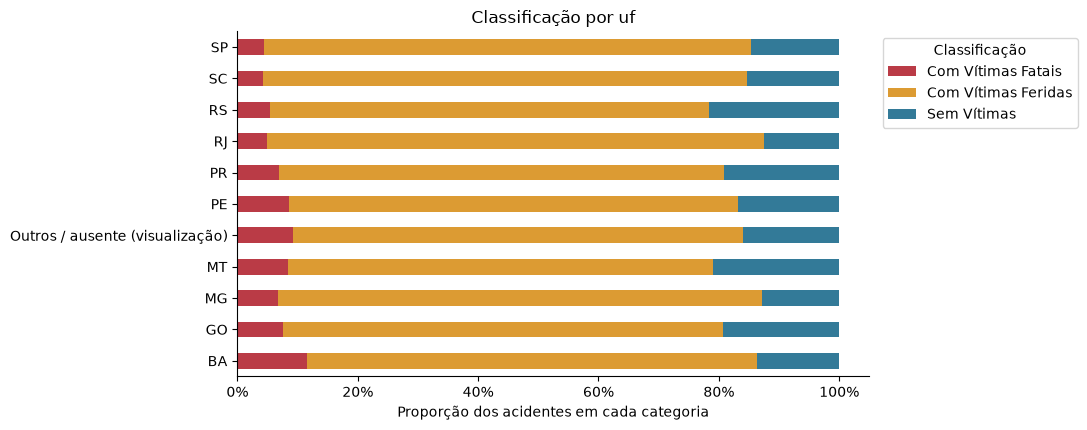

classificacao_acidente,Com Vítimas Feridas,Sem Vítimas,Com Vítimas Fatais
d0,67437,14189,6212
d1,22293,4813,2173
d2,22692,4534,2054


classificacao_acidente,Com Vítimas Feridas,Sem Vítimas,Com Vítimas Fatais
d0,76.774289,16.153601,7.07211
d1,76.139895,16.438403,7.421702
d2,77.5,15.484973,7.015027


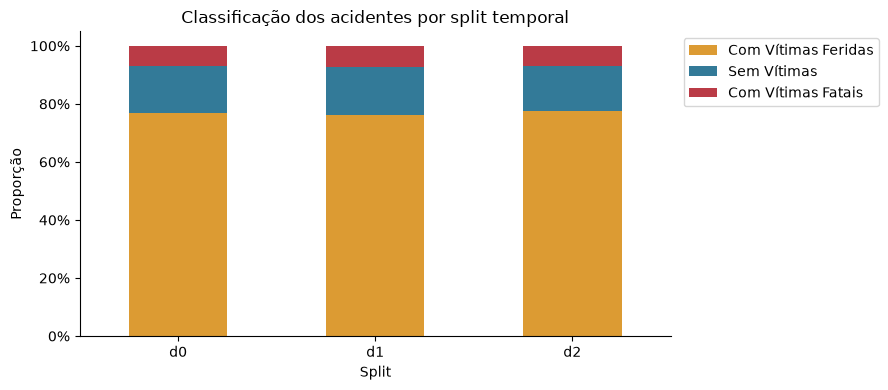

In [10]:
for column in ["tipo_acidente", "causa_acidente", "tipo_pista", "fase_dia", "condicao_metereologica", "uf"]:
    fig, counts = target_relation(ordered, column, FIGURE_DIR / f"target_by_{column}.png")
    plt.show()
    
split_counts = pd.DataFrame({name: part[TARGET].value_counts() for name, part in splits.items()}).fillna(0).T
split_proportions = split_counts.div(split_counts.sum(axis=1), axis=0)
display(split_counts)
display(split_proportions * 100)

fig, ax = plt.subplots(figsize=(9, 4))
split_proportions.plot.bar(stacked=True, ax=ax, rot=0, color=[CLASS_COLORS[c] for c in split_proportions.columns])

from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set(title="Classificação dos acidentes por split temporal", xlabel="Split", ylabel="Proporção")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

fig.tight_layout()
save_figure(fig, FIGURE_DIR / "eda_target_splits.png")
plt.show()

## 6. Mapas de D0, D1 e D2

Usamos a malha estadual do **geobr** e agrupamos por **UF + município**. A posição é a média das coordenadas das ocorrências, não o centroide oficial.

A área da bolha representa acidentes por mês equivalente (365,25/12 dias), considerando a duração inteira do split. A cor é a proporção de acidentes fatais, de 0% a 100%. As escalas são iguais nos três mapas e nenhum município é filtrado por quantidade mínima.

Municípios com poucos registros têm proporções instáveis; pontos podem se sobrepor. Os mapas não representam risco de acidente. A longitude vai até -30° para incluir Fernando de Noronha.

**Sobre o carregamento:** nesta versão do geobr, o download pode exibir `InsecureRequestWarning` porque a própria biblioteca faz a requisição sem verificar o certificado HTTPS. Esse aviso não interrompe a execução. Confira a mensagem “Malha carregada: 27 unidades federativas” e execute a célula seguinte para visualizar os mapas. Os avisos permanecem visíveis; o notebook não desativa a verificação de certificados.


In [11]:
# Requer internet; o geobr gerencia seu próprio cache, sem pasta extra no projeto.
states = geobr.read_state(code_state="all", year=2020, simplified=True).to_crs("EPSG:4326")
assert len(states) == 27 and not states.geometry.is_empty.any(), "Revisar malha de estados."
print(f"Malha carregada: {len(states)} unidades federativas. Execute a próxima célula para desenhar os mapas.")

municipalities = {}

for name, part in splits.items():
    duration_days = (part.timestamp.max() - part.timestamp.min()).total_seconds() / 86400 + 1 / 86400
    months = duration_days / (365.25 / 12)
    summary = part.assign(fatal=part[TARGET].eq("Com Vítimas Fatais")).groupby(["uf", "municipio"]).agg(
        longitude=("longitude", "mean"), latitude=("latitude", "mean"), acidentes=(TARGET, "size"), proporcao_fatal=("fatal", "mean")).reset_index()
    
    summary["acidentes_mes"] = summary.acidentes / months
    assert summary.acidentes.sum() == len(part), "Revisar localidades ausentes no mapa."
    municipalities[name] = summary

max_monthly = max(table.acidentes_mes.max() for table in municipalities.values())
size_scale = 700 / max_monthly
legend_values = [round(max_monthly / 10, 1), round(max_monthly / 2, 1), round(max_monthly, 1)]

D:\Workspace\ws-uem\acidentes-rodoviarios-ml\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


D:\Workspace\ws-uem\acidentes-rodoviarios-ml\.venv\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Malha carregada: 27 unidades federativas. Execute a próxima célula para desenhar os mapas.


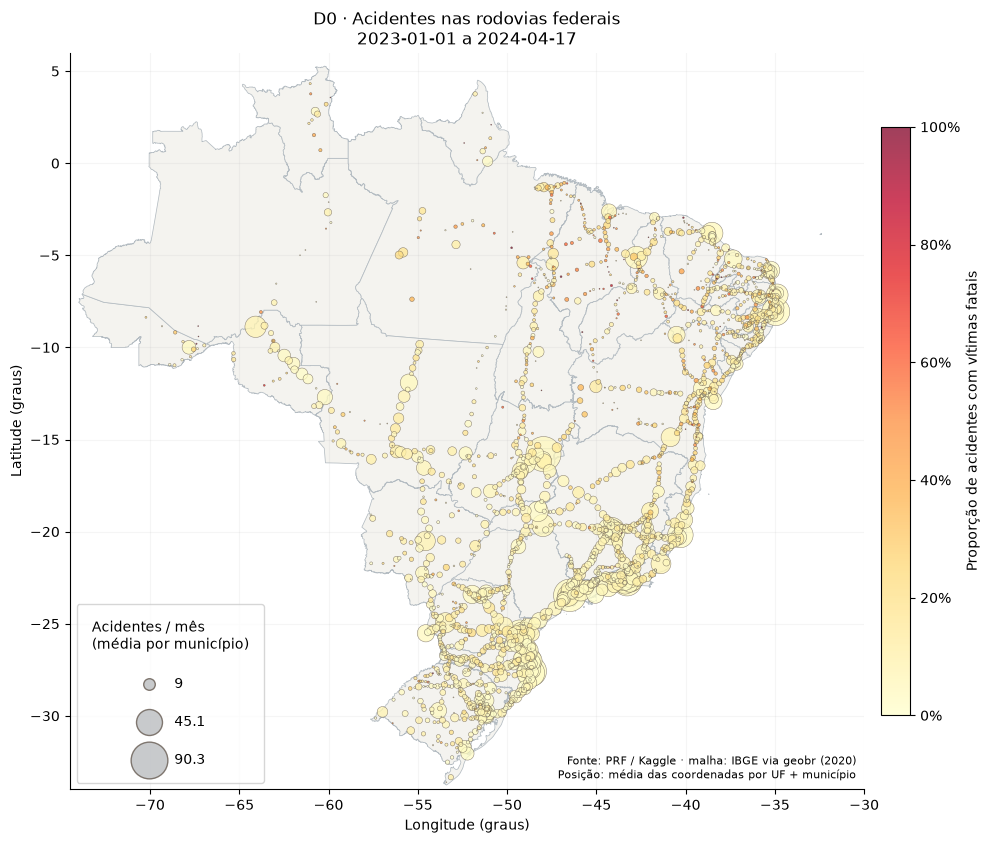

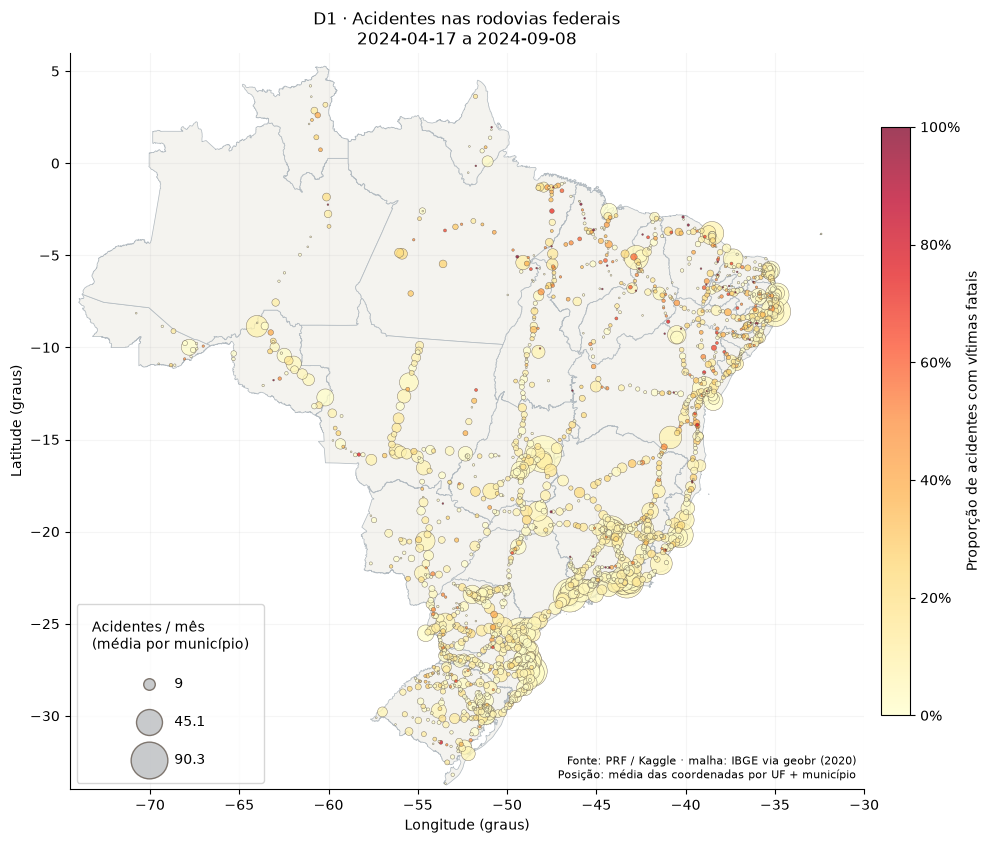

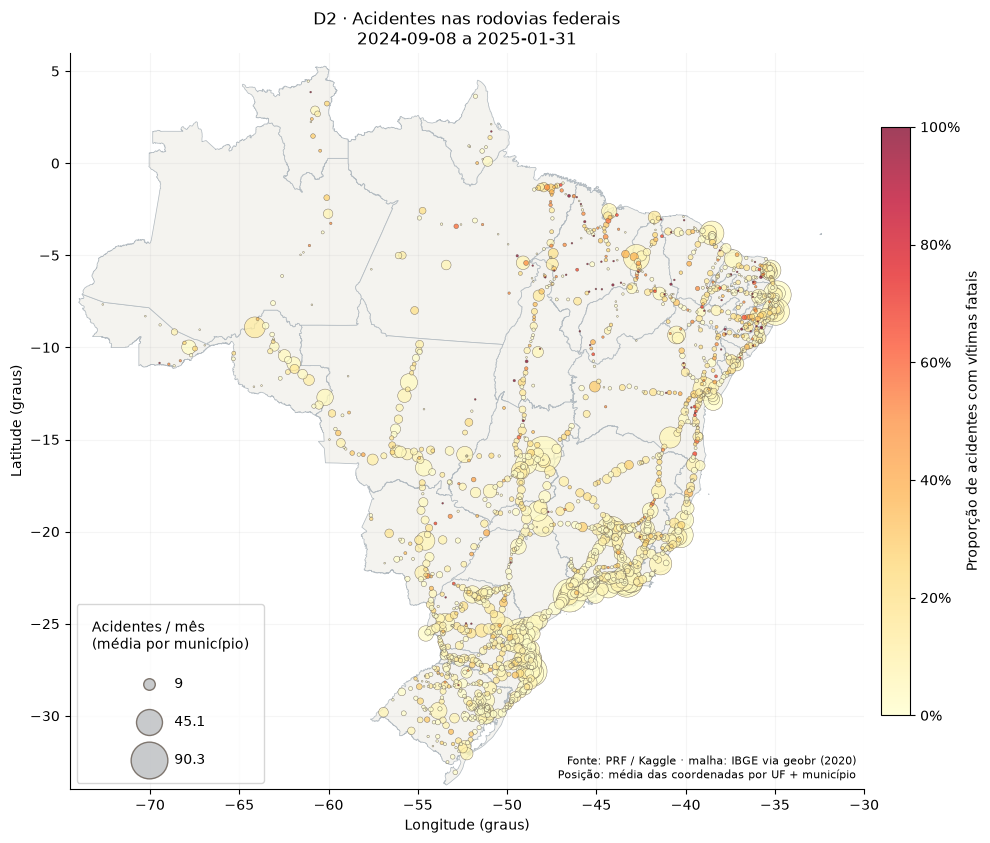

In [12]:
def plot_prf_split_map(summary, states, split_name, start_date, end_date, path, size_scale, legend_values):
    fig, ax = plt.subplots(figsize=(10, 10))
    states.plot(ax=ax, facecolor="#f4f3ef", edgecolor="#b4bcc2", linewidth=0.55)
    # menores por último para reduzir o encobrimento. Nenhum município é filtrado
    points = summary.sort_values("acidentes_mes", ascending=False)
    scatter = ax.scatter(points.longitude, points.latitude, s=points.acidentes_mes * size_scale,
                         c=points.proporcao_fatal, cmap="YlOrRd", norm=Normalize(0, 1),
                         alpha=0.75, edgecolors="#5d5147", linewidths=0.35)
    colorbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
    colorbar.set_label("Proporção de acidentes com vítimas fatais")
    colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1))
    handles = [ax.scatter([], [], s=v * size_scale, color="#b6b9bc", edgecolors="#5d5147", alpha=0.75)
               for v in legend_values]
    ax.legend(handles, [f"{v:g}" for v in legend_values], title="Acidentes / mês\n(média por município)",
              loc="lower left", labelspacing=1.7, borderpad=1.1)
    ax.set(xlim=(-74.5, -30), ylim=(-34, 6), xlabel="Longitude (graus)", ylabel="Latitude (graus)",
           title=f"{split_name.upper()} · Acidentes nas rodovias federais\n{str(start_date)[:10]} a {str(end_date)[:10]}")
    ax.text(0.99, 0.01, "Fonte: PRF / Kaggle · malha: IBGE via geobr (2020)\n"
            "Posição: média das coordenadas por UF + município", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8)
    ax.grid(alpha=0.12)
    fig.tight_layout()
    save_figure(fig, path)
    return fig


for name, summary in municipalities.items():
    part = splits[name]
    fig = plot_prf_split_map(summary, states, name, part.timestamp.min(), part.timestamp.max(), FIGURE_DIR / f"map_{name}.png", size_scale, legend_values)
    plt.show()

## 7. O que observamos nesta auditoria

- 146.400 registros originais; três sem classificação foram excluídos, restando **146.397**.
- Nenhuma duplicata exata ou ID repetido; as 17 features previstas estão completas nesta versão.
- Predominam acidentes com vítimas feridas; o desbalanceamento precisará ser considerado na modelagem.
- A ocorrência de Fernando de Noronha foi preservada.
- `tracado_via` tem 890 categorias, mantidas sem agrupamento.
- D0 tem 87.838 registros, D1 tem 29.279 e D2 tem 29.280. Há timestamps empatados nas duas fronteiras.

Esta análise é descritiva e não confirma concept drift. A próxima etapa será comparar as distribuições temporais.